# Ödev 1: Makine Öğrenmesi Yöntemleriyle Sınıflandırma

**Ad Soyad:** Yasemin Deniz Öztürk

**Öğrenci No:** 427611

**GitHub Linki:**
https://github.com/yaseminndenizozturk/Derin_Ogrenme_Odev_1.git
---
**Özet:** Bu çalışmada, *Breast Cancer Wisconsin* veri seti kullanılarak iyi huylu (benign) ve kötü huylu (malignant) tümörlerin sınıflandırılması gerçekleştirilmiştir. Çalışma kapsamında iki farklı ekolden gelen modern algoritmalar kullanılmış; **Derin Öğrenme (Yapay Sinir Ağları)** ile Gradient Boosting tabanlı **CatBoost** algoritmasının performansları karşılaştırmalı olarak analiz edilmiştir.

In [3]:
# HÜCRE 1: Kütüphanelerin Yüklenmesi
!pip install catboost -q  # CatBoost yüklü değilse sessizce kurar

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow Versiyonu:", tf.__version__)
import catboost
print("CatBoost Versiyonu:", catboost.__version__)

TensorFlow Versiyonu: 2.19.0
CatBoost Versiyonu: 1.2.10


## 1. Veri Ön İşleme Adımları
Veri setinin her iki model için de hazır hale getirilmesi sürecinde şu adımlar izlenmiştir:
1. **Veri Temizleme:** Sınıflandırma için gereksiz olan `id` sütunu ve tamamen boş olan `Unnamed: 32` sütunu veri setinden çıkarılmıştır.
2. **Etiketleme:** Hedef değişken olan `diagnosis` sütunundaki 'M' (Kötü Huylu) değerleri **1**, 'B' (İyi Huylu) değerleri **0** olarak sayısal formata dönüştürülmüştür.
3. **Veri Bölme:** Modelin genelleme yeteneğini ölçmek için veri seti **%80 Eğitim** ve **%20 Test** olarak ayrılmıştır.
4. **Ölçeklendirme:** Derin öğrenme ve uzaklık tabanlı hesaplamaların düzgün çalışabilmesi için özellikler `StandardScaler` ile standartlaştırılmıştır. (Not: CatBoost ölçeklendirme gerektirmese de, karşılaştırmanın adil olması adına iki modele de aynı ölçeklenmiş veri verilmiştir).

In [4]:
# HÜCRE 2: Veri Ön İşleme
df = pd.read_csv('data (1).csv')

# Gereksiz sütunların atılması
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# Etiketleme: M -> 1, B -> 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Eğitim ve Test seti ayırımı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Eğitim verisi boyutu: {X_train_scaled.shape}")
print(f"Test verisi boyutu: {X_test_scaled.shape}")

Eğitim verisi boyutu: (455, 30)
Test verisi boyutu: (114, 30)


## 2. Seçilen Algoritmalar ve Seçim Nedenleri

Bu sınıflandırma problemini çözmek ve farklı yaklaşımların performanslarını kıyaslamak amacıyla iki güçlü makine öğrenmesi algoritması seçilmiştir:

* **1. Derin Öğrenme (MLP / Yapay Sinir Ağı):** Veri setinde yer alan 30 farklı sayısal özellik ile tümörün cinsi (iyi/kötü huylu) arasındaki doğrusal olmayan (non-linear) ve karmaşık ilişkileri en hassas şekilde yakalayabilmek için seçilmiştir. Modelin eğitim verisini ezberlemesini (overfitting) önlemek amacıyla mimariye %30 oranında Dropout (unutma) katmanı eklenerek 3 gizli katmanlı bir ağ tasarlanmıştır.

* **2. CatBoost Sınıflandırıcı (Gradient Boosting):** Yandex tarafından geliştirilen ve karar ağaçları (Decision Trees) üzerinde çalışan modern bir algoritmadır. Tıbbi veriler gibi yapısal/tablosal (tabular) verilerde genellikle en yüksek doğruluğu sağladığı için tercih edilmiştir. Derin öğrenme algoritmalarının aksine, 569 satır gibi nispeten küçük veri setlerinde bile çok yüksek performans ve stabilite gösterebilme yeteneğine sahiptir.

In [5]:
# HÜCRE 3: Modellerin Eğitimi

# ---------------------------------------------------------
# 1. DERİN ÖĞRENME MODELİ (TENSORFLOW / KERAS)
# ---------------------------------------------------------
print("--- 1. Derin Öğrenme Modeli Eğitiliyor ---")
model_dl = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_dl.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# Çıktı kalabalığı yapmaması için verbose=0 kullanıldı, grafiklerle analiz edeceğiz
history_dl = model_dl.fit(X_train_scaled, y_train, epochs=30, batch_size=16, validation_split=0.2, verbose=0)
print("Derin Öğrenme eğitimi tamamlandı.\n")

# ---------------------------------------------------------
# 2. CATBOOST MODELİ
# ---------------------------------------------------------
print("--- 2. CatBoost Modeli Eğitiliyor ---")
model_cat = CatBoostClassifier(
    iterations=200,          # 200 karar ağacı
    learning_rate=0.05,      # Öğrenme hızı
    depth=6,                 # Ağaç derinliği
    eval_metric='Accuracy',
    verbose=0,               # Çıktıları gizle
    random_seed=42
)

# CatBoost'a eğitim ve doğrulama (test) setini veriyoruz
model_cat.fit(X_train_scaled, y_train, eval_set=(X_test_scaled, y_test))
print("CatBoost eğitimi tamamlandı.")

--- 1. Derin Öğrenme Modeli Eğitiliyor ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Derin Öğrenme eğitimi tamamlandı.

--- 2. CatBoost Modeli Eğitiliyor ---
CatBoost eğitimi tamamlandı.


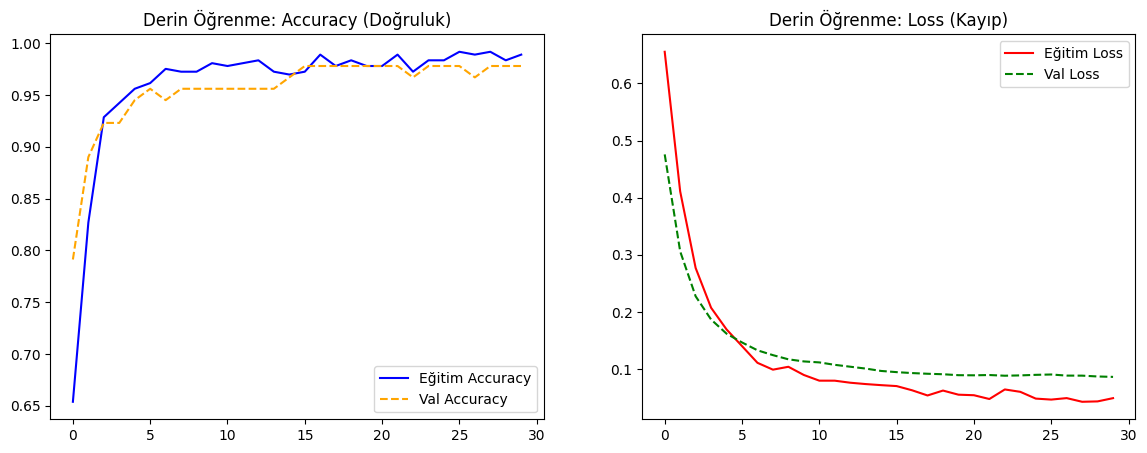


DERİN ÖĞRENME (YAPAY SİNİR AĞLARI) SONUÇLARI
                    precision    recall  f1-score   support

 İyi Huylu - B (0)       0.97      0.99      0.98        71
Kötü Huylu - M (1)       0.98      0.95      0.96        43

          accuracy                           0.97       114
         macro avg       0.97      0.97      0.97       114
      weighted avg       0.97      0.97      0.97       114

-> İyi Huylu Sınıfı için Specificity (Seçicilik): %98.59

CATBOOST (GRADIENT BOOSTING) SONUÇLARI
                    precision    recall  f1-score   support

 İyi Huylu - B (0)       0.97      0.99      0.98        71
Kötü Huylu - M (1)       0.98      0.95      0.96        43

          accuracy                           0.97       114
         macro avg       0.97      0.97      0.97       114
      weighted avg       0.97      0.97      0.97       114

-> İyi Huylu Sınıfı için Specificity (Seçicilik): %98.59


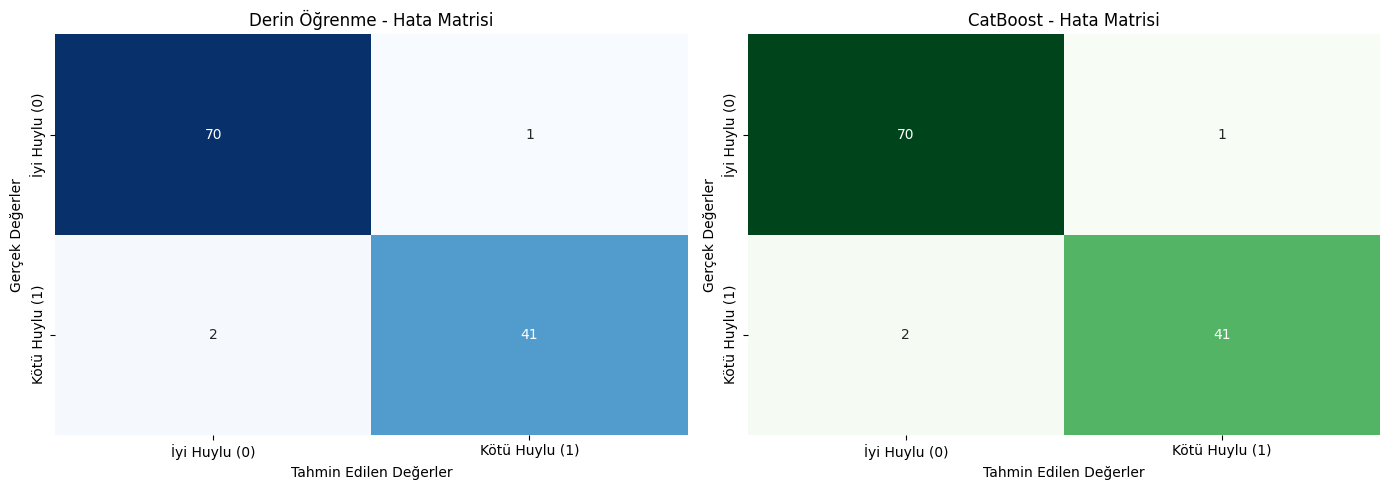

In [6]:
# HÜCRE 4: Değerlendirme, Karşılaştırma ve Görselleştirme

def print_metrics(y_true, y_pred, model_name):
    """Metrikleri ve Specificity değerini hesaplar ve yazdırır."""
    print(f"\n{'='*40}\n{model_name} SONUÇLARI\n{'='*40}")
    print(classification_report(y_true, y_pred, target_names=['İyi Huylu - B (0)', 'Kötü Huylu - M (1)']))

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)
    print(f"-> İyi Huylu Sınıfı için Specificity (Seçicilik): %{specificity*100:.2f}")
    return cm

# --- 1. DERİN ÖĞRENME EĞİTİM GRAFİKLERİ ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_dl.history['accuracy'], label='Eğitim Accuracy', color='blue')
ax1.plot(history_dl.history['val_accuracy'], label='Val Accuracy', color='orange', linestyle='--')
ax1.set_title('Derin Öğrenme: Accuracy (Doğruluk)')
ax1.legend()

ax2.plot(history_dl.history['loss'], label='Eğitim Loss', color='red')
ax2.plot(history_dl.history['val_loss'], label='Val Loss', color='green', linestyle='--')
ax2.set_title('Derin Öğrenme: Loss (Kayıp)')
ax2.legend()
plt.show()

# --- 2. TAHMİNLER VE METRİKLER ---
# Derin Öğrenme Tahminleri
y_pred_probs_dl = model_dl.predict(X_test_scaled, verbose=0)
y_pred_dl = (y_pred_probs_dl > 0.5).astype("int32")
cm_dl = print_metrics(y_test, y_pred_dl, "DERİN ÖĞRENME (YAPAY SİNİR AĞLARI)")

# CatBoost Tahminleri
y_pred_cat = model_cat.predict(X_test_scaled)
cm_cat = print_metrics(y_test, y_pred_cat, "CATBOOST (GRADIENT BOOSTING)")

# --- 3. KARMAŞIKLIK MATRİSİ (CONFUSION MATRIX) KARŞILAŞTIRMASI ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
class_names = ['İyi Huylu (0)', 'Kötü Huylu (1)']

sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, cbar=False, ax=ax1)
ax1.set_title("Derin Öğrenme - Hata Matrisi")
ax1.set_ylabel('Gerçek Değerler')
ax1.set_xlabel('Tahmin Edilen Değerler')

sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names, cbar=False, ax=ax2)
ax2.set_title("CatBoost - Hata Matrisi")
ax2.set_ylabel('Gerçek Değerler')
ax2.set_xlabel('Tahmin Edilen Değerler')

plt.tight_layout()
plt.show()

.


.

.

.

.
.

.

.

.

.

.
.

.

.

.

.
.

.

.

.

.

.
.

.

.

.

.

.

.

.

.

.

.

.

## 3. Sonuçların Karşılaştırılması ve Yorumlanması

Bu çalışmada kullanılan iki modelin test verisi üzerindeki performansı incelendiğinde, her iki algoritmanın da birebir aynı ve oldukça yüksek başarı metriklerine ulaştığı görülmüştür:

1. **Performans Analizi:**
   * Her iki model de (Derin Öğrenme ve CatBoost) test verisi üzerinde genel olarak **%97 Accuracy (Doğruluk)** oranına ulaşmıştır.
   * Kötü huylu (Malignant) tümörlerin tespitinde her iki model de **%98 Precision (Kesinlik)** ve **%95 Recall (Duyarlılık)** değerleri vermiştir.
   * Sağlıklı (İyi huylu) dokuları doğru ayırt etme gücünü gösteren **Specificity (Seçicilik)** değeri iki model için de **%98.59** olarak hesaplanmıştır.

2. **Tıbbi Açıdan Değerlendirme:**
   Meme kanseri tanısı gibi hayati risk taşıyan tıbbi problemlerde en tehlikeli durum "Kötü huylu" bir tümörü gözden kaçırmaktır (False Negative). Modellerin %95 Recall (Duyarlılık) değerine ulaşması, gerçekte kanserli olan hastaların büyük çoğunluğunun başarıyla tespit edildiğini göstermektedir. %98.59'luk Specificity (Seçicilik) değeri ise modelin "yanlış alarm" (False Positive) verme ihtimalinin son derece düşük olduğunu, yani iyi huylu tümörlerin gereksiz yere kötü huylu olarak etiketlenmediğini kanıtlamaktadır.

3. **Algoritmik Karşılaştırma ve Sonuç:**
   İki tamamen farklı mimariden gelen (Yapay Sinir Ağları ve Ağaç Tabanlı Gradient Boosting) algoritmanın aynı sonuçları vermesi tesadüf değildir. *Breast Cancer Wisconsin* veri seti (569 satır, 30 öznitelik) temiz, iyi yapılandırılmış ve nispeten küçük ölçekli bir veri setidir. Bu özellikler doğrultusunda, her iki model de veri setinin barındırdığı örüntüleri maksimum seviyede öğrenmiş ve aynı karar sınırlarını (decision boundaries) oluşturmuştur.
   
   Bununla birlikte pratik uygulama ve verimlilik göz önüne alındığında, bu tür yapısal (tabular) veri setleri için **CatBoost algoritması daha avantajlı olarak değerlendirilebilir.** Derin Öğrenme modelleri veri ölçeklendirme (scaling), uygun katman mimarisi seçimi, epoch ayarı ve yüksek işlem gücü gerektirirken; CatBoost algoritması karmaşık veri ön işleme adımlarına ihtiyaç duymadan, çok daha kısa sürede aynı yüksek başarı oranına ulaşabilmektedir.

## 4. ROC Eğrisi (Receiver Operating Characteristic) ve AUC Analizi
Modellerin sınıflandırma eşik değerlerinden bağımsız olarak genel başarımlarını karşılaştırmak amacıyla ROC eğrileri çizdirilmiş ve Eğri Altında Kalan Alan (AUC - Area Under Curve) skorları hesaplanmıştır. AUC değerinin 1.0'a yaklaşması, modelin sınıfları birbirinden ayırt etme gücünün mükemmel olduğunu gösterir.

MODellerİn AUC (Eğri Altında Kalan Alan) SKORLARI
-> Derin Öğrenme (MLP) AUC Skoru : 0.9961
-> CatBoost AUC Skoru            : 0.9961



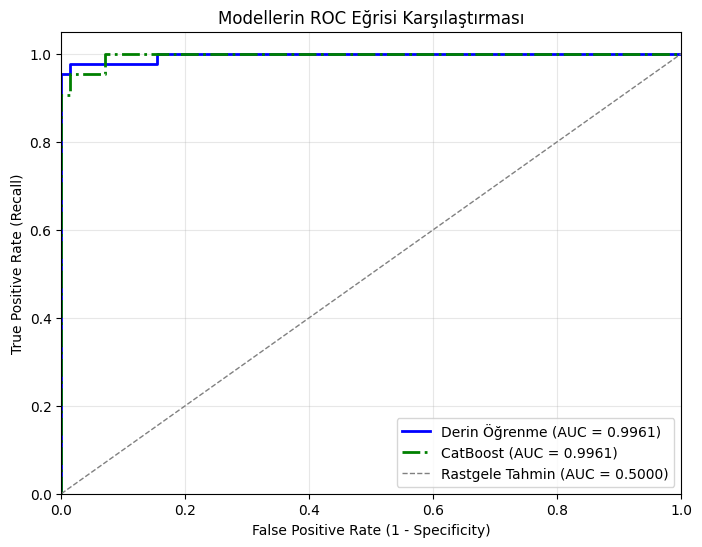

In [7]:
# HÜCRE 5: ROC Eğrisi ve AUC Hesaplamaları
from sklearn.metrics import roc_curve, auc

# 1. Derin Öğrenme Modeli için Olasılıkların Hesaplanması
y_pred_probs_dl = model_dl.predict(X_test_scaled, verbose=0).ravel()
fpr_dl, tpr_dl, thresholds_dl = roc_curve(y_test, y_pred_probs_dl)
auc_dl = auc(fpr_dl, tpr_dl)

# 2. CatBoost Modeli için Olasılıkların Hesaplanması
y_pred_probs_cat = model_cat.predict_proba(X_test_scaled)[:, 1]
fpr_cat, tpr_cat, thresholds_cat = roc_curve(y_test, y_pred_probs_cat)
auc_cat = auc(fpr_cat, tpr_cat)

# --- AUC SKORLARININ EKRANA YAZDIRILMASI ---
print(f"{'='*40}")
print("MODellerİn AUC (Eğri Altında Kalan Alan) SKORLARI")
print(f"{'='*40}")
print(f"-> Derin Öğrenme (MLP) AUC Skoru : {auc_dl:.4f}")
print(f"-> CatBoost AUC Skoru            : {auc_cat:.4f}")
print(f"{'='*40}\n")

# 3. ROC Eğrisinin Çizdirilmesi
plt.figure(figsize=(8, 6))

# Derin Öğrenme Eğrisi
plt.plot(fpr_dl, tpr_dl, color='blue', lw=2,
         label=f'Derin Öğrenme (AUC = {auc_dl:.4f})')

# CatBoost Eğrisi
plt.plot(fpr_cat, tpr_cat, color='green', lw=2, linestyle='-.',
         label=f'CatBoost (AUC = {auc_cat:.4f})')

# Rastgele Tahmin Çizgisi
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Rastgele Tahmin (AUC = 0.5000)')

# Grafik Ayarları
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Modellerin ROC Eğrisi Karşılaştırması')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)